In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv(r"/content/plants_dataset_euhm_itai_07.csv")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
data.head()

,Soil Type,Sunlight (hours/day),Water Supply (liters/week),Temperature (C),pH Level,Plant Species,Thrives
0,Sandy,1.54,8.94,11.35,8.23,Fern,0
1,Sandy,2.67,36.45,NaN,8.40,Rose,0
2,Sandy,9.27,8.15,24.98,7.23,Cactus,1
3,Loamy,5.45,26.95,9.05,8.42,NaN,0
4,Loamy,8.19,21.08,21.62,6.96,Rose,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Soil Type                   195 non-null    object 
 1   Sunlight (hours/day)        188 non-null    float64
 2   Water Supply (liters/week)  195 non-null    float64
 3   Temperature (C)             189 non-null    float64
 4   pH Level                    187 non-null    float64
 5   Plant Species               189 non-null    object 
 6   Thrives                     200 non-null    int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 11.1+ KB


In [6]:
data.isna().sum()

,0
Soil Type,5
Sunlight (hours/day),12
Water Supply (liters/week),5
Temperature (C),11
pH Level,13
Plant Species,11
Thrives,0


In [7]:
null_coulomns = ["Soil Type" , "Sunlight (hours/day)" , "Water Supply (liters/week)" , "Temperature (C)" , "pH Level" , "Plant Species"]
for col in null_coulomns:
    if data[col].dtype.name == "object":
        data[col] = data[col].fillna(data[col].mode()[0])
    elif data[col].dtype.name in ["float64" , "int64"]:
        data[col] = data[col].fillna(data[col].median())


In [8]:
data.isna().sum()

,0
Soil Type,0
Sunlight (hours/day),0
Water Supply (liters/week),0
Temperature (C),0
pH Level,0
Plant Species,0
Thrives,0


In [9]:
from sklearn.preprocessing import LabelEncoder
cat_coulomns = ["Soil Type" , "Plant Species"]
le = {}
for col in cat_coulomns:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])
    le[col] = encoder

In [10]:
data.head()

,Soil Type,Sunlight (hours/day),Water Supply (liters/week),Temperature (C),pH Level,Plant Species,Thrives
0,2,1.54,8.94,11.35,8.23,1,0
1,2,2.67,36.45,22.65,8.40,2,0
2,2,9.27,8.15,24.98,7.23,0,1
3,1,5.45,26.95,9.05,8.42,2,0
4,1,8.19,21.08,21.62,6.96,2,1


In [11]:
from sklearn.preprocessing import StandardScaler
num_coulomns = ["Sunlight (hours/day)" , "Water Supply (liters/week)" , "Temperature (C)" , "pH Level"]
scale = StandardScaler()
data[num_coulomns] = scale.fit_transform(data[num_coulomns])


In [12]:
data.head()

,Soil Type,Sunlight (hours/day),Water Supply (liters/week),Temperature (C),pH Level,Plant Species,Thrives
0,2,-1.394674,-0.762842,-1.183424,1.207668,1,0
1,2,-1.106278,1.545114,-0.028515,1.344720,2,0
2,2,0.578157,-0.829119,0.209621,0.401481,0,1
3,1,-0.396774,0.748110,-1.418494,1.360843,2,0
4,1,0.302522,0.255645,-0.133786,0.183811,2,1


In [13]:
summary = data.describe()
print(summary)

        Soil Type  Sunlight (hours/day)  Water Supply (liters/week)  \
count  200.000000          2.000000e+02                2.000000e+02   
mean     1.140000         -1.787459e-16               -1.598721e-16   
std      0.844967          1.002509e+00                1.002509e+00   
min      0.000000         -1.532491e+00               -1.428970e+00   
25%      0.000000         -7.949129e-01               -9.065127e-01   
50%      1.000000         -4.584981e-02               -7.993534e-02   
75%      2.000000          7.440481e-01                7.613237e-01   
max      2.000000          1.785335e+00                1.842942e+00   

       Temperature (C)      pH Level  Plant Species     Thrives  
count     2.000000e+02  2.000000e+02     200.000000  200.000000  
mean     -2.087219e-16 -1.110223e-16       1.060000    0.500000  
std       1.002509e+00  1.002509e+00       0.830572    0.501255  
min      -1.832422e+00 -1.783285e+00       0.000000    0.000000  
25%      -5.413254e-01 -7.6748

<Axes: xlabel='Thrives', ylabel='Count'>

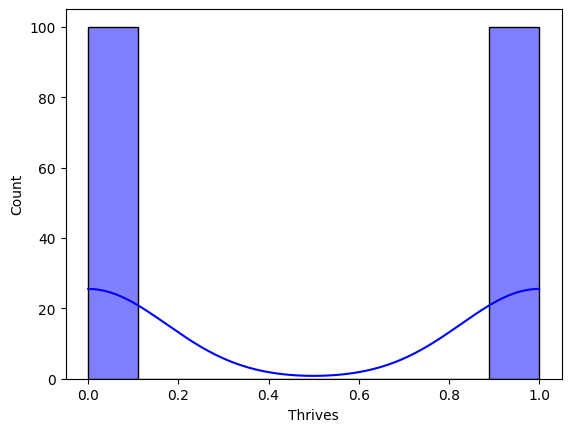

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data["Thrives"],color = "blue" , kde = True)

<Axes: xlabel='pH Level', ylabel='Thrives'>

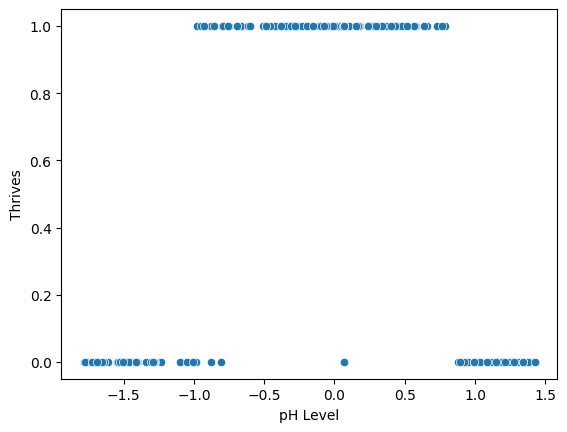

In [15]:
sns.scatterplot(data = data , x = "pH Level" , y = "Thrives")

<Axes: xlabel='Plant Species', ylabel='Thrives'>

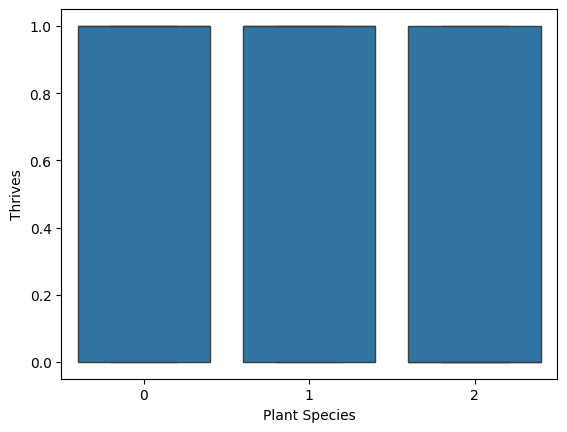

In [19]:
sns.boxplot(data = data , x = "Plant Species" , y = "Thrives")

In [20]:
from sklearn.model_selection import train_test_split
x = data.drop(["Thrives"] , axis = 1)
y = data["Thrives"]
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2 , random_state = 42)

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
dt = DecisionTreeClassifier()
dt.fit(x_train , y_train)
dt_y_pred = dt.predict(x_test)
print("accuracy_score =",accuracy_score(y_test , dt_y_pred))
print("classification_report =",classification_report(y_test , dt_y_pred))
print("confusion_matrix =",confusion_matrix(y_test , dt_y_pred))

accuracy_score = 0.9
classification_report =               precision    recall  f1-score   support

           0       0.90      0.90      0.90        21
           1       0.89      0.89      0.89        19

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40

confusion_matrix = [[19  2]
 [ 2 17]]


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
lr = LogisticRegression()
lr.fit(x_train , y_train)
lr_y_pred = lr.predict(x_test)
print("accuracy_score =",accuracy_score(y_test , lr_y_pred))
print("classification_report =",classification_report(y_test , lr_y_pred))
print("confusion_matrix =",confusion_matrix(y_test , lr_y_pred))

accuracy_score = 0.6
classification_report =               precision    recall  f1-score   support

           0       0.63      0.57      0.60        21
           1       0.57      0.63      0.60        19

    accuracy                           0.60        40
   macro avg       0.60      0.60      0.60        40
weighted avg       0.60      0.60      0.60        40

confusion_matrix = [[12  9]
 [ 7 12]]


<Axes: ylabel='Thrives'>

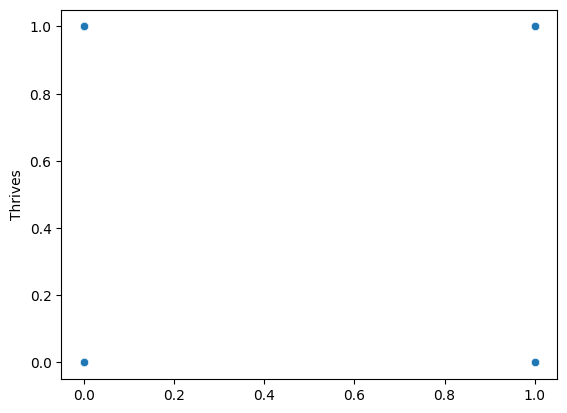

In [23]:
sns.scatterplot(x = lr_y_pred , y = y_test)

In [24]:
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
grid_params = {
    "max_depth" : [x for x in range(25,50)],
    "max_leaf_nodes" : [x for x in range(50,75)]
}
grid_model = RandomizedSearchCV(DecisionTreeClassifier(),grid_params , cv = 5)
grid_model.fit(x_train , y_train)
print(grid_model.best_params_)
print(grid_model.best_score_)

{'max_leaf_nodes': 70, 'max_depth': 35}
0.9875


In [25]:
data.columns

Index(['Soil Type', 'Sunlight (hours/day)', 'Water Supply (liters/week)',
       'Temperature (C)', 'pH Level', 'Plant Species', 'Thrives'],
      dtype='object')

In [26]:
def predict(st, sl, ws, temp, ph, ps):
    try:
        input_data = pd.DataFrame({
            "Soil Type": [st],
            "Sunlight (hours/day)": [sl],
            "Water Supply (liters/week)": [ws],
            "Temperature (C)": [temp],
            "pH Level": [ph],
            "Plant Species": [ps],
        })

        for col in cat_coulomns:
            input_data[col] = le[col].transform(input_data[col])

        input_data[num_coulomns] = scale.transform(input_data[num_coulomns])

        prediction = dt.predict(input_data)[0]

        if prediction == 1:
            return "Yes "
        else:
            return " No"

    except Exception as e:
        return f" Error: {e}"

In [27]:
import gradio as gr
gr.Interface(
    fn = predict,
    inputs = [
        gr.Dropdown(label = "Soil Type" , choices = ["Sandy" , "Loamy" , "Clay"]),
        gr.Number(label = "Sunlight (hours/day)"),
        gr.Number(label = "Water Supply (liters/week)"),
        gr.Number(label = "Temperature (C)"),
        gr.Number(label = "pH Level"),
        gr.Dropdown(label = "Plant Species" , choices = ["Fern" , "Rose" , "Cactus"]),
    ],
    outputs = "text",
    title = "plants thrives",
).launch()



It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a432083ee37900f785.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
